- we have two types of scaling

    - Z score (standardization)

    - min max scalar (normalaization)

-Zscore

-z=x-u/singma

- sigma is standard deviation

- u mean

- x

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [19]:
file_path=r'C:\Users\vijay\Documents\NareshIT\data_files\Visadataset.csv'
visa_df=pd.read_csv(file_path)
cat=visa_df.select_dtypes(include='object').columns
num=visa_df.select_dtypes(exclude='object').columns

In [20]:
cat,num

(Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
        'requires_job_training', 'region_of_employment', 'unit_of_wage',
        'full_time_position', 'case_status'],
       dtype='object'),
 Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object'))

In [21]:
# step - take pwage data
# step 2 - calculate the mean of data
# step 3 calculate std of the data
# step 4 Nr= data-mean step1-step2
# step 5 z_wage=Nr/std = step4/step3
# step 6 create a new column visa_df=['Z_wage']=z_wage

In [22]:
wage_data=visa_df['prevailing_wage']
wage_mean=wage_data.mean()
wage_std=wage_data.std()
Nr=wage_data-wage_mean
z_wage=Nr/wage_std
visa_df['Z_Wage']=z_wage

In [23]:
df=visa_df[['prevailing_wage','Z_Wage']]

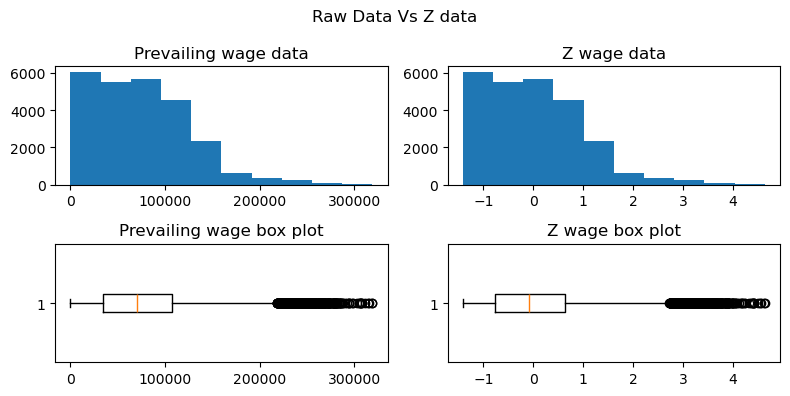

In [25]:
#layout='constrained'
plt.figure(figsize=(8,4))
plt.suptitle('Raw Data Vs Z data')
plt.subplot(2,2,1).hist(wage_data)
plt.title('Prevailing wage data')
plt.subplot(2,2,2).hist(z_wage)
plt.title('Z wage data')
plt.subplot(2,2,3).boxplot(wage_data,vert=False)
plt.title('Prevailing wage box plot')
plt.subplot(2,2,4).boxplot(z_wage,vert=False)
plt.title('Z wage box plot')
plt.tight_layout() 
plt.show()

**StandardScalar**

  - sklearn

  - preprocessing

  - StandardScalar


In [9]:
#file_path=r'C:\Users\vijay\Documents\NareshIT\data_files\Visadataset.csv'
#visa_df=pd.read_csv(file_path)
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
#wage_ss=sc.fit_transform(visa_df[['prevailing_wage']])
wage_ss=sc.fit_transform(visa_df['prevailing_wage'].values.reshape(-1,1))
visa_df['wage_ss']=wage_ss


In [10]:
visa_df[['prevailing_wage','Z_Wage','wage_ss']]

,prevailing_wage,Z_Wage,wage_ss
0,592.2029,-1.398510,-1.398537
1,83425.6500,0.169832,0.169835
2,122996.8600,0.919060,0.919079
3,83434.0300,0.169991,0.169994
4,149907.3900,1.428576,1.428604
...,...,...,...
25475,77092.5700,0.049923,0.049924
25476,279174.7900,3.876083,3.876159
25477,146298.8500,1.360253,1.360280
25478,86154.7700,0.221504,0.221509


**MinmaxScalar**

- setp 1 read data

- step 2 calculate min

- step 3 calculate max

- step 4 Nr=step1-step2

- step 5 Dr=step3-step2

- step 6 Nr/Dr

- step 7 visa_df=[wage_min_max]=Nr/Dr

In [13]:
visa_df['prevailing_wage'].min(),visa_df['prevailing_wage'].max()

(2.1367, 319210.27)

In [15]:
wagen_data=visa_df['prevailing_wage']
wagen_min=wagen_data.min()
wagen_max=wagen_data.max()
Nr= (wagen_data-wagen_min)
print(Nr)
Dr= (wagen_max-wagen_min)
print(Dr)
wage_min_max=Nr/Dr
visa_df['wage_min_max']=wage_min_max

0           590.0662
1         83423.5133
2        122994.7233
3         83431.8933
4        149905.2533
            ...     
25475     77090.4333
25476    279172.6533
25477    146296.7133
25478     86152.6333
25479     70874.7733
Name: prevailing_wage, Length: 25480, dtype: float64
319208.13330000004


In [16]:
from sklearn.preprocessing import MinMaxScaler
sm=MinMaxScaler()
#wage_ss=sc.fit_transform(visa_df[['prevailing_wage']])
wage_s_min_max=sm.fit_transform(visa_df['prevailing_wage'].values.reshape(-1,1))
visa_df['wage_s_min_max']=wage_s_min_max


In [17]:
visa_df[['prevailing_wage','Z_Wage','wage_ss','wage_s_min_max','wage_min_max']]

,prevailing_wage,Z_Wage,wage_ss,wage_s_min_max,wage_min_max
0,592.2029,-1.398510,-1.398537,0.001849,0.001849
1,83425.6500,0.169832,0.169835,0.261345,0.261345
2,122996.8600,0.919060,0.919079,0.385312,0.385312
3,83434.0300,0.169991,0.169994,0.261371,0.261371
4,149907.3900,1.428576,1.428604,0.469616,0.469616
...,...,...,...,...,...
25475,77092.5700,0.049923,0.049924,0.241505,0.241505
25476,279174.7900,3.876083,3.876159,0.874579,0.874579
25477,146298.8500,1.360253,1.360280,0.458311,0.458311
25478,86154.7700,0.221504,0.221509,0.269895,0.269895
